In [9]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split

# import  settings
import plot_settings
plot_settings.apply()

In [82]:
# Load data
X_train = np.load('data/0.5_feature.npz')['arr_0'][:, 1:]
y_train = np.load('data/0.5_target.npz')['arr_0']


# X_train = np.ones((100, 3)) * X_train
# print(X_train[:2, :])
# print(y_train)
print(X_train.shape, y_train.shape)

(2479, 20) (2479, 20)


In [13]:
# # Split data into training, validation, and test sets
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [83]:
input_shape = X_train.shape
output_shape = y_train.shape
print(input_shape, output_shape)

(2479, 20) (2479, 20)


In [93]:
model = keras.models.Sequential([   
    keras.layers.Input(shape=(input_shape[1],)),
    keras.layers.Dense(64, activation='tanh'),
    keras.layers.Dense(64),
    keras.layers.Dense(64),
    keras.layers.Dense(20, activation='relu'),
])

In [94]:
model.compile(
  optimizer='adam',
  loss='mse',metrics=['accuracy'])

In [95]:
epochs = 150     ## Number of epoch to run
batch_size = 32  ## Number of samples per gradient update

es = keras.callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights = True)
# Train the model
history = model.fit(
  X_train, y_train,
  epochs=epochs,
  verbose = 1,
  callbacks=[es]
  #validation_data=(X_valid, y_valid)
  )

Epoch 1/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.0000e+00 - loss: 1594546816.0000  
Epoch 2/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.0000e+00 - loss: 1489418752.0000
Epoch 3/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - accuracy: 0.0000e+00 - loss: 1047858112.0000
Epoch 4/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.0000e+00 - loss: 506812064.0000
Epoch 5/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - accuracy: 0.0000e+00 - loss: 349645728.0000
Epoch 6/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - accuracy: 0.3288 - loss: 341606816.0000   
Epoch 7/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 1.0000 - loss: 340586720.0000
Epoch 8/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 1.0000 - loss: 340359808.0000
Epoch 9/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step - accuracy: 1.0000 - loss: 340324352.0000
Epoch 10/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 1.0000 - loss: 340323584.0000
Epoch 11/150
78/78 ━━

Text(0, 0.5, 'Loss')

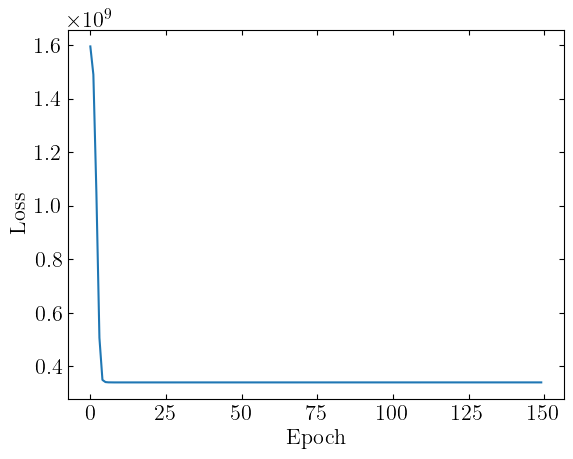

In [96]:
train_loss = history.history['loss']
# val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training loss')
# plt.plot(val_loss, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')